In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

# Load the data
data = pd.read_csv('C:\\Users\\Liman\\Downloads\\Data (1).csv') 

#preparing data for logistic regression

data["admitted"]=data["admitted"].map({"yes": 1, "no": 0})   #convert admitted variable into numerical

data.head()

,gmat,gpa,work_experience,admitted
0,780,4.0,3,1
1,750,3.9,4,1
2,690,3.3,3,0
3,710,3.7,5,1
4,680,3.9,4,0


In [2]:
#import relevant libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
#features extraction
x = data[['gmat', 'gpa','work_experience']]
y = data['admitted']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=0)  
#splitting data with test size of 25%
logreg = LogisticRegression()   #build our logistic model
logreg.fit(x_train, y_train)  #fitting training data
y_pred  = logreg.predict(x_test)    #testing model’s performance
print("Accuracy={:.2f}".format(logreg.score(x_test, y_test)))

Accuracy=0.80


<Axes: xlabel='gmat', ylabel='admitted'>

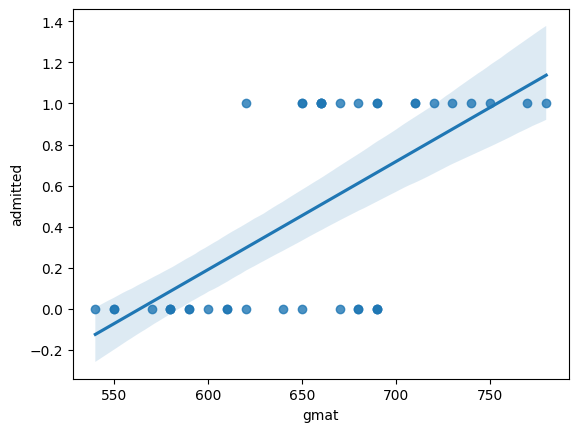

In [5]:
import seaborn as sns
sns.regplot(x='gmat',y='admitted',data=data)

In [6]:
import pandas as pd

data = {'Nom': ['Ali', 'Sami', None, 'Nora'],
        'Age': [25, None, 30, 22]}
df = pd.DataFrame(data)

print("Avant :")
print(df)

# Supprime les lignes contenant des NaN
df_clean = df.dropna()

print("\nAprès dropna :")
print(df_clean)


Avant :
    Nom   Age
0   Ali  25.0
1  Sami   NaN
2  None  30.0
3  Nora  22.0

Après dropna :
    Nom   Age
0   Ali  25.0
3  Nora  22.0


In [7]:
df_filled = df.fillna({'Nom': 'Inconnu', 'Age': 0})
print(df_filled)


       Nom   Age
0      Ali  25.0
1     Sami   0.0
2  Inconnu  30.0
3     Nora  22.0


In [9]:
print(df.loc[3])

Nom    Nora
Age    22.0
Name: 3, dtype: object


In [10]:
print(df.loc[:, ['Nom']])

    Nom
0   Ali
1  Sami
2  None
3  Nora


In [11]:
print(df.loc[0:2, ['Nom', 'Age']])


    Nom   Age
0   Ali  25.0
1  Sami   NaN
2  None  30.0


In [12]:
print(df.iloc[0])


Nom     Ali
Age    25.0
Name: 0, dtype: object


In [13]:
print(df.iloc[0:2, 0])


0     Ali
1    Sami
Name: Nom, dtype: object


In [17]:
data = {
    'Nom': ['Ali', 'Sami', None, 'Nora', 'Karim'],
    'Age': [25, None, 30, 22, None],
    'Ville': ['Alger', 'Oran', 'Constantine', None, 'Tlemcen']
}

df = pd.DataFrame(data)
df

,Nom,Age,Ville
0,Ali,25.0,Alger
1,Sami,NaN,Oran
2,None,30.0,Constantine
3,Nora,22.0,None
4,Karim,NaN,Tlemcen


In [18]:
df_drop = df.dropna()
df_drop

,Nom,Age,Ville
0,Ali,25.0,Alger


In [20]:
df_filna = df.fillna({
    'Nom':'Inconnu',
    'Age':df['Age'].mean(),
    'Ville':'Non précisée'
}
)
df_filna

,Nom,Age,Ville
0,Ali,25.000000,Alger
1,Sami,25.666667,Oran
2,Inconnu,30.000000,Constantine
3,Nora,22.000000,Non précisée
4,Karim,25.666667,Tlemcen


In [21]:
print("\nloc :\n", df_filna.loc[2, ['Nom', 'Ville']])



loc :
 Nom          Inconnu
Ville    Constantine
Name: 2, dtype: object


In [23]:
print("\nloc plage :\n", df_filna.loc[0:2, ['Nom']])


loc plage :
        Nom
0      Ali
1     Sami
2  Inconnu


In [24]:
print("\niloc ligne 0 :\n", df_filna.iloc[0])



iloc ligne 0 :
 Nom        Ali
Age       25.0
Ville    Alger
Name: 0, dtype: object


In [25]:
print("\niloc plage :\n", df_filna.iloc[0:3, 0:2])


iloc plage :
        Nom        Age
0      Ali  25.000000
1     Sami  25.666667
2  Inconnu  30.000000


In [26]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# 1️⃣ Générer les données (courbe quadratique + bruit)
np.random.seed(0)
X = np.linspace(-3, 3, 50).reshape(-1, 1)
y = X**2 + np.random.randn(50, 1) * 2

# 2️⃣ Séparer les données en train et test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3️⃣ Tester plusieurs degrés de complexité
degrees = [1, 2, 10]

print("Comparaison des erreurs :")
print("-" * 40)

for d in degrees:
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_error = mean_squared_error(y_train, y_train_pred)
    test_error = mean_squared_error(y_test, y_test_pred)

    print(f"Modèle degré {d}:")
    print(f"  Erreur Entraînement : {train_error:.2f}")
    print(f"  Erreur Test         : {test_error:.2f}")
    print("-" * 40)


Comparaison des erreurs :
----------------------------------------
Modèle degré 1:
  Erreur Entraînement : 12.49
  Erreur Test         : 14.21
----------------------------------------
Modèle degré 2:
  Erreur Entraînement : 4.81
  Erreur Test         : 3.57
----------------------------------------
Modèle degré 10:
  Erreur Entraînement : 4.11
  Erreur Test         : 6.52
----------------------------------------
